# Temporal Sequence Action Recognition
**Approach:** Instead of classifying single frames (which overfits badly due to near-duplicate video frames), we classify a **buffer of N consecutive frames** from the same bee as one action.

**Pipeline:**
1. Extract DINOv2-small CLS token features for every image → save to disk (run once)
2. Group images into temporal sequences per bee per video
3. Train a lightweight Temporal Transformer on top of pre-computed features

**Why this fixes overfitting:**
- Each training sample is one *random window* from a bee sequence → forces learning of motion patterns, not texture memorisation
- Effective training set size = number of unique bee sequences (hundreds), not number of frames (thousands)
- DINOv2 stays frozen → no risk of fine-tuning away general visual features

In [2]:
import os
import re
import random
import pickle
from collections import defaultdict, Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler

print("Imports OK")

Imports OK


## Configuration
Change `BUFFER_SIZE` here to test different temporal windows (8, 12, 16 ...).

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_DIR   = "D:/Projects/Masters/Data/AR_merged_dataset"
OUTPUT_DIR    = "D:/Projects/Masters/ActionRecognition"
FEATURES_PATH = os.path.join(OUTPUT_DIR, "features.pkl")  # cached DINOv2 features (run once)

# ── Sequence params ─────────────────────────────────────────────────────────────
BUFFER_SIZE = 16   # frames per sample — try 8 / 12 / 16
MIN_SEQ_LEN = 2    # discard sequences shorter than this
VAL_STRIDE  = 8    # stride between val windows (overlap = BUFFER_SIZE - VAL_STRIDE)

# ── Model architecture ──────────────────────────────────────────────────────────
FEATURE_DIM = 384  # DINOv2-small CLS token size
NUM_CLASSES = 3
NUM_HEADS   = 4    # transformer attention heads
NUM_LAYERS  = 2    # transformer encoder layers
DROPOUT     = 0.3

# ── Training ────────────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
# NUM_WORKERS must be 0 on Windows + Jupyter — multiprocessing spawn deadlocks
# when pickling the large features dict to worker processes.
# Since features are already in RAM (no image I/O), 0 workers is just as fast.
NUM_WORKERS  = 0
MAX_EPOCHS   = 60
PATIENCE     = 12
LR           = 3e-4
WEIGHT_DECAY = 0.05

# ── Save path (includes buffer size so multiple runs don't overwrite each other) ─
SAVE_PATH = os.path.join(OUTPUT_DIR, f"best_temporal_buf{BUFFER_SIZE}.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"Buffer size : {BUFFER_SIZE} frames")
print(f"Save path   : {SAVE_PATH}")

Device      : cuda
Buffer size : 16 frames
Save path   : D:/Projects/Masters/ActionRecognition\best_temporal_buf16.pt


## Step 1 — Extract DINOv2 Features (run once)
Runs DINOv2-small over all 105k images and saves the 384-dim CLS token for each.
Saved to `features.pkl`. Skip automatically if the file already exists.

Expected time: ~10-15 min on GPU. File size: ~160 MB.

In [4]:
def extract_features(dataset_dir, save_path, batch_size=128):
    """
    Runs DINOv2-small on all images in dataset_dir/{train,val}/{class}/ and saves
    the CLS token features as features[split][stem] = np.array([384]).
    Returns the feature dict (loaded from disk if already computed).
    """
    if os.path.exists(save_path):
        print(f"Features already exist at:\n  {save_path}\nLoading...")
        with open(save_path, "rb") as f:
            return pickle.load(f)

    print("Extracting DINOv2 features (this runs once)...")
    backbone = AutoModel.from_pretrained("facebook/dinov2-small").to(device)
    backbone.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    features = {"train": {}, "val": {}}

    for split in ["train", "val"]:
        split_dir = os.path.join(dataset_dir, split)
        for label in sorted(os.listdir(split_dir)):
            label_dir = os.path.join(split_dir, label)
            if not os.path.isdir(label_dir):
                continue
            files = sorted(os.listdir(label_dir))
            batch_imgs, batch_stems = [], []

            def flush_batch():
                if not batch_imgs:
                    return
                with torch.no_grad(), autocast("cuda"):
                    imgs_t = torch.stack(batch_imgs).to(device)
                    out    = backbone(imgs_t)
                    cls    = out.last_hidden_state[:, 0].cpu().float().numpy()
                for s, f in zip(batch_stems, cls):
                    features[split][s] = f
                batch_imgs.clear()
                batch_stems.clear()

            for fname in tqdm(files, desc=f"{split}/{label}"):
                stem = os.path.splitext(fname)[0]
                img  = Image.open(os.path.join(label_dir, fname)).convert("RGB")
                batch_imgs.append(transform(img))
                batch_stems.append(stem)
                if len(batch_imgs) == batch_size:
                    flush_batch()
            flush_batch()

    # Free GPU memory before training
    del backbone
    torch.cuda.empty_cache()

    with open(save_path, "wb") as f:
        pickle.dump(features, f, protocol=4)
    print(f"Saved features → {save_path}")
    return features


features = extract_features(DATASET_DIR, FEATURES_PATH)
print(f"\nTrain features: {len(features['train']):,}")
print(f"Val   features: {len(features['val']):,}")

Features already exist at:
  D:/Projects/Masters/ActionRecognition\features.pkl
Loading...

Train features: 88,260
Val   features: 17,634


## Step 2 — Build Temporal Sequences

Parse filenames to recover temporal order:

| Class | Pattern | Group key | Sort by |
|---|---|---|---|
| fanning / trophallaxis | `{action}_{video}_{frame:05d}_{bee_id}` | `(video, bee_id)` | frame number |
| neutral | `neutral_{video}_tile{tile}_{det_id}_{global_frame}` | `(video, tile)` | global frame |

Result: a list of `(label_idx, [stems in temporal order])` per split.

In [5]:
CLASS_TO_IDX = {"fanning": 0, "neutral": 1, "trophallaxis": 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

# Regexes for each class
_RE_ACTION  = re.compile(r"^(fanning|trophallaxis)_(.+?)_(\d{5})_(\d+)$")
_RE_NEUTRAL = re.compile(r"^neutral_(.+?)_tile(\d+)_(\d+)_(\d+)$")


def parse_stem(stem):
    """
    Returns (label_idx, group_key, sort_key) or None if unparseable.
    group_key  — unique identifier for a single bee tracked through time
    sort_key   — integer used to put frames in chronological order
    """
    m = _RE_ACTION.match(stem)
    if m:
        action, video, frame, bee = m.group(1), m.group(2), int(m.group(3)), m.group(4)
        return CLASS_TO_IDX[action], (video, bee), frame

    m = _RE_NEUTRAL.match(stem)
    if m:
        video, tile = m.group(1), m.group(2)
        global_frame = int(m.group(4))
        # Group all detections in the same spatial tile of the same video together;
        # global_frame gives chronological order within that tile.
        return CLASS_TO_IDX["neutral"], (video, tile), global_frame

    return None, None, None


def build_sequences(features_split, dataset_dir, split, min_seq_len):
    """
    Returns list of (label_idx, [stems_in_temporal_order]).
    Sequences shorter than min_seq_len are discarded.
    """
    # (label_idx, group_key) → [(sort_key, stem)]
    groups = defaultdict(list)
    unparsed = 0

    split_dir = os.path.join(dataset_dir, split)
    for label in sorted(os.listdir(split_dir)):
        if label not in CLASS_TO_IDX:
            continue
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for fname in os.listdir(label_dir):
            stem = os.path.splitext(fname)[0]
            if stem not in features_split:
                continue
            label_idx, group_key, sort_key = parse_stem(stem)
            if group_key is None:
                unparsed += 1
                continue
            groups[(label_idx, group_key)].append((sort_key, stem))

    if unparsed:
        print(f"  Warning: {unparsed} filenames could not be parsed (skipped)")

    sequences = []
    for (label_idx, _), items in groups.items():
        items.sort(key=lambda x: x[0])  # chronological order
        stems = [s for _, s in items]
        if len(stems) >= min_seq_len:
            sequences.append((label_idx, stems))

    return sequences


print("Building sequences...")
train_sequences = build_sequences(features["train"], DATASET_DIR, "train", MIN_SEQ_LEN)
val_sequences   = build_sequences(features["val"],   DATASET_DIR, "val",   MIN_SEQ_LEN)

print(f"\nTrain sequences : {len(train_sequences):,}")
print(f"Val   sequences : {len(val_sequences):,}")

for name, seqs in [("Train", train_sequences), ("Val", val_sequences)]:
    counts  = Counter(IDX_TO_CLASS[lbl] for lbl, _ in seqs)
    lengths = [len(s) for _, s in seqs]
    print(f"\n{name} distribution:")
    for cls in ["fanning", "neutral", "trophallaxis"]:
        print(f"  {cls:15s}: {counts[cls]:>5} sequences")
    print(f"  Sequence length — min: {min(lengths)}, median: {int(np.median(lengths))}, max: {max(lengths)}")

Building sequences...

Train sequences : 4,288
Val   sequences : 881

Train distribution:
  fanning        :    65 sequences
  neutral        :  4202 sequences
  trophallaxis   :    21 sequences
  Sequence length — min: 2, median: 3, max: 4626

Val distribution:
  fanning        :    12 sequences
  neutral        :   858 sequences
  trophallaxis   :    11 sequences
  Sequence length — min: 2, median: 3, max: 2904


## Step 3 — SequenceDataset

Each sample is a window of `BUFFER_SIZE` consecutive frames from one bee sequence.

- **Train:** random window start per epoch (cheap data augmentation, avoids memorising fixed windows)
- **Val:** all stride-d windows (ensures every frame is evaluated at least once)

In [6]:
class SequenceDataset(Dataset):
    def __init__(self, features, sequences, buffer_size, split="train", stride=None):
        """
        features    : dict {stem -> np.array [384]}
        sequences   : list of (label_idx, [stems in order])
        buffer_size : T - number of frames per sample
        split       : "train" (random window + augmentation) or "val" (strided windows, no aug)
        stride      : step between val windows (default = buffer_size // 2)
        """
        self.features    = features
        self.buffer_size = buffer_size
        self.split       = split

        if split == "train":
            self.samples = sequences
        else:
            stride = stride or max(1, buffer_size // 2)
            self.samples = []
            for label_idx, stems in sequences:
                N = len(stems)
                if N < buffer_size:
                    self.samples.append((label_idx, stems, 0))
                else:
                    for start in range(0, N - buffer_size + 1, stride):
                        self.samples.append((label_idx, stems, start))

    def __len__(self):
        return len(self.samples)

    def _get_window(self, stems, start):
        """Extract BUFFER_SIZE frames starting at `start`, repeating last frame if short."""
        T = self.buffer_size
        N = len(stems)
        feats, mask = [], []
        for i in range(T):
            idx = start + i
            if idx < N:
                feats.append(torch.from_numpy(self.features[stems[idx]].copy()))
                mask.append(False)
            else:
                feats.append(torch.from_numpy(self.features[stems[N - 1]].copy()))
                mask.append(True)
        return torch.stack(feats), torch.tensor(mask, dtype=torch.bool)

    def _augment(self, x, mask):
        """
        Feature-space augmentations applied during training only.

        1. Gaussian noise  - adds tiny variation to each feature vector, simulating
           slight visual differences between similar frames (lighting, motion blur).
           Prevents the model from relying on exact feature values.

        2. Temporal reverse - a reversed fanning sequence is still fanning (wing
           motion is cyclical). Applied randomly so the model learns
           direction-invariant temporal patterns.

        3. Temporal jitter  - randomly replaces up to 2 real frames with a
           neighbouring frame. Simulates duplicate frames or missed detections
           that will occur during real inference.
        """
        # 1. Gaussian noise
        x = x + torch.randn_like(x) * 0.02

        # 2. Temporal reverse (50% chance, real frames only)
        if random.random() < 0.5:
            n_real = int((~mask).sum())
            if n_real > 1:
                x[:n_real] = x[:n_real].flip(0)

        # 3. Temporal jitter - replace up to 2 random real frames with a neighbour
        n_real = int((~mask).sum())
        if n_real > 2:
            for _ in range(random.randint(0, min(2, n_real - 1))):
                i = random.randint(0, n_real - 2)
                x[i] = x[i + 1]

        return x

    def __getitem__(self, idx):
        if self.split == "train":
            label_idx, stems = self.samples[idx]
            N     = len(stems)
            start = random.randint(0, max(0, N - self.buffer_size))
        else:
            label_idx, stems, start = self.samples[idx]

        x, mask = self._get_window(stems, start)

        if self.split == "train":
            x = self._augment(x, mask)

        return x, torch.tensor(label_idx, dtype=torch.long), mask


## Step 4 — Temporal Sequence Classifier

```
Input: [B, T, 384]  (T pre-computed DINOv2 CLS tokens)
  → prepend learnable [CLS] token → [B, T+1, 384]
  → add positional embeddings
  → 2-layer Transformer Encoder (pre-norm, 4 heads)
  → CLS output [B, 384]
  → MLP → [B, 3]
```

Total trainable params ≈ 1.5M  (compare: 22M for DINOv2, which stays frozen).

In [7]:
class TemporalSequenceClassifier(nn.Module):
    def __init__(self, feature_dim=384, num_classes=3, num_heads=4,
                 num_layers=2, dropout=0.3, max_seq_len=33):
        """
        max_seq_len : BUFFER_SIZE + 1 (extra slot for the prepended CLS token)
        """
        super().__init__()

        # Learnable classification token (like BERT/ViT)
        self.cls_token = nn.Parameter(torch.randn(1, 1, feature_dim) * 0.02)

        # One embedding per position (pos 0 = CLS, pos 1..T = frames)
        self.pos_embed = nn.Embedding(max_seq_len, feature_dim)

        # Temporal transformer (pre-norm is more stable than post-norm)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model        = feature_dim,
            nhead          = num_heads,
            dim_feedforward= feature_dim * 2,   # 768
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(feature_dim)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pos_embed.weight, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, padding_mask=None):
        """
        x            : [B, T, feature_dim]  — frame feature vectors
        padding_mask : [B, T] bool          — True means this position is padding
        """
        B, T, _ = x.shape

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)       # [B, 1, D]
        x   = torch.cat([cls, x], dim=1)              # [B, T+1, D]

        # Positional encoding
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0)  # [1, T+1]
        x   = x + self.pos_embed(pos)

        # Extend padding mask: CLS is never masked
        if padding_mask is not None:
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            full_mask = torch.cat([cls_mask, padding_mask], dim=1)  # [B, T+1]
        else:
            full_mask = None

        # Temporal self-attention
        x = self.transformer(x, src_key_padding_mask=full_mask)  # [B, T+1, D]

        # Classify from CLS token output
        return self.classifier(self.norm(x[:, 0]))               # [B, num_classes]

## Step 5 — Training Utilities

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for feats, labels, masks in tqdm(loader, desc="Train", leave=False):
        feats  = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast("cuda"):
            logits = model(feats, padding_mask=masks)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for feats, labels, masks in tqdm(loader, desc="Val", leave=False):
            feats  = feats.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            with autocast("cuda"):
                logits = model(feats, padding_mask=masks)
                loss   = criterion(logits, labels)

            total_loss += loss.item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")

## Step 6 — Build DataLoaders

In [9]:
train_dataset = SequenceDataset(
    features["train"], train_sequences, BUFFER_SIZE, split="train"
)
val_dataset = SequenceDataset(
    features["val"], val_sequences, BUFFER_SIZE, split="val", stride=VAL_STRIDE
)

print(f"Train dataset : {len(train_dataset):,} samples  (1 random window per sequence per epoch)")
print(f"Val   dataset : {len(val_dataset):,} samples  (all stride-{VAL_STRIDE} windows)")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

# Quick sanity check
feats_b, labels_b, masks_b = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  features : {feats_b.shape}   (batch × frames × feature_dim)")
print(f"  labels   : {labels_b.shape}")
print(f"  masks    : {masks_b.shape}  — padding fraction: {masks_b.float().mean():.3f}")

# Class weights based on sequence counts (not image counts)
seq_counts = Counter(lbl for lbl, _ in train_sequences)
total_seqs = sum(seq_counts.values())
class_weights = torch.tensor(
    [total_seqs / (NUM_CLASSES * seq_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
)
print(f"\nClass weights (from sequence counts):")
for i, w in enumerate(class_weights):
    print(f"  {IDX_TO_CLASS[i]:15s}: {seq_counts[i]:>5} seqs  →  weight {w:.4f}")

Train dataset : 4,288 samples  (1 random window per sequence per epoch)
Val   dataset : 2,488 samples  (all stride-8 windows)

Batch shapes:
  features : torch.Size([64, 16, 384])   (batch × frames × feature_dim)
  labels   : torch.Size([64])
  masks    : torch.Size([64, 16])  — padding fraction: 0.689

Class weights (from sequence counts):
  fanning        :    65 seqs  →  weight 21.9897
  neutral        :  4202 seqs  →  weight 0.3402
  trophallaxis   :    21 seqs  →  weight 68.0635


## Step 7 — Initialise Model, Optimiser, Scheduler

In [10]:
model = TemporalSequenceClassifier(
    feature_dim = FEATURE_DIM,
    num_classes = NUM_CLASSES,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    max_seq_len = BUFFER_SIZE + 1,   # +1 for the CLS token
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Temporal model params : {total_params:,}")

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# Simple cosine decay — more stable than warm restarts when model converges fast.
# T_max = MAX_EPOCHS means LR decays smoothly to eta_min over the full run.
# No sudden LR jumps that destabilise an already-good solution.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
scaler    = GradScaler()

# Output shape check
with torch.no_grad():
    dummy = torch.randn(2, BUFFER_SIZE, FEATURE_DIM).to(device)
    out   = model(dummy)
print(f"Output shape check    : {out.shape}  (should be [2, {NUM_CLASSES}])")

Temporal model params : 2,425,091


c:\Users\Anurath\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Output shape check    : torch.Size([2, 3])  (should be [2, 3])


## Step 8 — Training Loop

In [11]:
best_val_f1       = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device, scaler
    )
    val_loss, val_f1 = validate(model, val_loader, criterion, device)
    scheduler.step()
    torch.cuda.empty_cache()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    lr_now = scheduler.get_last_lr()[0]
    print(
        f"Epoch {epoch:3d} "
        f"| Train Loss {train_loss:.4f}  F1 {train_f1:.4f} "
        f"| Val Loss {val_loss:.4f}  F1 {val_f1:.4f} "
        f"| LR {lr_now:.2e}"
    )

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        epochs_no_improve = 0
        torch.save(
            {
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "val_f1"     : val_f1,
                "config": {
                    "buffer_size": BUFFER_SIZE,
                    "feature_dim": FEATURE_DIM,
                    "num_classes" : NUM_CLASSES,
                    "num_heads"   : NUM_HEADS,
                    "num_layers"  : NUM_LAYERS,
                    "dropout"     : DROPOUT,
                },
            },
            SAVE_PATH,
        )
        print(f"  ✓ Saved best model  (Val F1: {best_val_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  ✗ No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nTraining complete. Best Val F1: {best_val_f1:.4f}")

Epoch   1 | Train Loss 0.9648  F1 0.3619 | Val Loss 2.2458  F1 0.1962 | LR 3.00e-04
  ✓ Saved best model  (Val F1: 0.1962)


Epoch   2 | Train Loss 0.7528  F1 0.4705 | Val Loss 0.6196  F1 0.5353 | LR 2.99e-04
  ✓ Saved best model  (Val F1: 0.5353)


Epoch   3 | Train Loss 0.5671  F1 0.5421 | Val Loss 1.3138  F1 0.4732 | LR 2.98e-04
  ✗ No improvement (1/12)


Epoch   4 | Train Loss 0.7379  F1 0.6050 | Val Loss 0.3832  F1 0.9003 | LR 2.97e-04
  ✓ Saved best model  (Val F1: 0.9003)


Epoch   5 | Train Loss 0.4506  F1 0.5998 | Val Loss 0.9571  F1 0.6966 | LR 2.95e-04
  ✗ No improvement (1/12)


...

Epoch  26 | Train Loss 0.0921  F1 0.9435 | Val Loss 0.3083  F1 0.9392 | LR 1.82e-04
  ✗ No improvement (8/12)


Epoch  27 | Train Loss 0.0736  F1 0.9511 | Val Loss 0.4864  F1 0.9095 | LR 1.74e-04
  ✗ No improvement (9/12)


Epoch  28 | Train Loss 0.1824  F1 0.9411 | Val Loss 0.5314  F1 0.8923 | LR 1.66e-04
  ✗ No improvement (10/12)


Epoch  29 | Train Loss 0.0405  F1 0.9666 | Val Loss 1.2153  F1 0.7912 | LR 1.58e-04
  ✗ No improvement (11/12)


Epoch  30 | Train Loss 0.2595  F1 0.9357 | Val Loss 0.2084  F1 0.9449 | LR 1.51e-04
  ✗ No improvement (12/12)

Early stopping at epoch 30.

Training complete. Best Val F1: 0.9631


## Step 9 — Evaluation & Visualisation

Loaded best model from epoch 18  (Val F1: 0.9631)


Evaluating: 100%|██████████| 39/39 [00:00<00:00, 109.55it/s]



Classification Report:
              precision    recall  f1-score   support

     fanning       0.99      0.94      0.97      1214
     neutral       0.97      1.00      0.98       863
trophallaxis       0.91      0.98      0.94       411

    accuracy                           0.97      2488
   macro avg       0.96      0.97      0.96      2488
weighted avg       0.97      0.97      0.97      2488



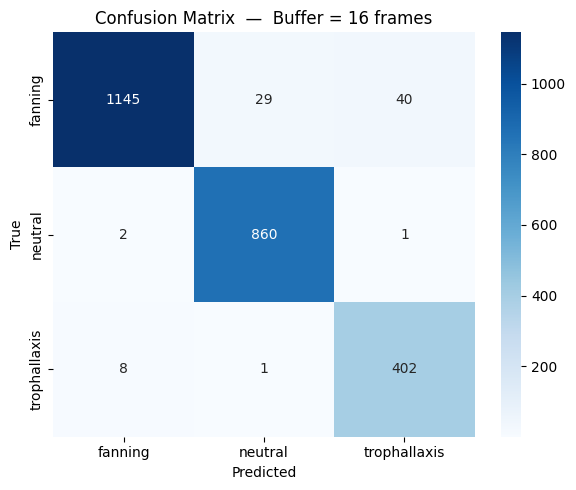

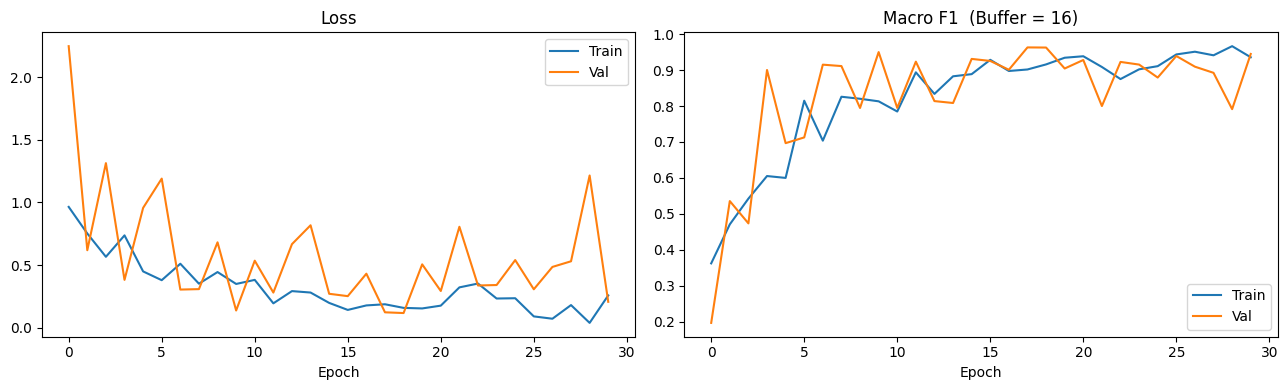

In [12]:
# Load best checkpoint
ckpt = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']}  (Val F1: {ckpt['val_f1']:.4f})")

all_preds, all_labels = [], []
with torch.no_grad():
    for feats, labels, masks in tqdm(val_loader, desc="Evaluating"):
        logits = model(feats.to(device), padding_mask=masks.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

classes = ["fanning", "neutral", "trophallaxis"]
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ── Confusion matrix ────────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix  —  Buffer = {BUFFER_SIZE} frames")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_buf{BUFFER_SIZE}.png"), dpi=150)
plt.show()

# ── Training curves ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_f1"], label="Train")
ax2.plot(history["val_f1"],   label="Val")
ax2.set_title(f"Macro F1  (Buffer = {BUFFER_SIZE})")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"curves_buf{BUFFER_SIZE}.png"), dpi=150)
plt.show()

## Notes for End-to-End Integration

At inference time (in `end_to_end.ipynb`), the pipeline becomes:

1. **Detection** — YOLO gives bounding boxes per frame
2. **Track bees** — maintain a rolling buffer of the last `BUFFER_SIZE` DINOv2 features per tracked bee
3. **Classify** — once buffer is full, run `TemporalSequenceClassifier` → action label

The saved checkpoint includes the full config dict so you can reconstruct the model without hardcoding sizes:
```python
ckpt   = torch.load('best_temporal_buf16.pt')
cfg    = ckpt['config']
model  = TemporalSequenceClassifier(**cfg)
model.load_state_dict(ckpt['model_state'])
```